# Lab: ANN in R and Python

**Instructions**

* Read and work through the demonstration content on your own
* Complete all exercises below for the `python part` in a `.ipynb` notebook 
* Complete all exercises below for the `R part` in a `.rmd` notebook 

**Submission:**

* You need to upload TWO document to Canvas when you are done. 
  * A PDF (or HTML) of the completed form of the Python lab-assignment notebook
  * A PDF (or HTML) of the completed form of the R lab-assignment notebook
* The final uploaded version should NOT have any code-errors present. 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

# Demonstration: ANN in Python


## MLP Model 

* Here we show an example of a simple ANN architecture, the notable features are
  * A two node input layer, two hidden layers with three and two nodes respectively, sigmoidal activation on the hidden layers, linear activation on the output layer, and 20 fitting parameters composing the various sub-matrices.
  * **Note**: The convention on the counting of the hidden layers may vary, some conventions would say this has three hidden layers (i.e. counting the inter-connections as hidden-layers, not the nodes themselves)
* This model can be easily modified for scalar regression, vector regression, binary classification, and multi-class classification, depending on the structure and activation function of the output layer.

![](img/2023-03-19-19-02-18.png)

## Sk-learn MLP

* To train artificial neural networks (ANN), generally we need to do numerical optimization, as discussed in Module-1. 
* In this lab, we will do our neural-network training using a `dense feed-forward` fully connected ANN, implemented in `Sk-learn`. For more information see the following useful links. 
  * [ Multi-layer Perceptron](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#neural-networks-supervised)
  * [sklearn.neural_network.MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)
  * [sklearn.neural_network.MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor)
* To train more complicated ANN models, you would typically use `Pytorch`, `Tensorflow`, or `Tensor-flow` using the `Keras` API. If you are interested in learning more about `deep learning` then consider taking `ANLY-590` 

### Methods 

* To do `ANN` regression with Sk-learn we can call the Multi-layer Perceptron regressor or classifier.
* This model numerically `optimizes` the `squared error` loss using either `LBFGS` or `stochastic gradient descent`

### Arguments 

The function `sklearn.neural_network.MLPRegressor` and `sklearn.neural_network.MLPClassifier` functions have many input arguments. Here we call attention to some of the most important of these  

**hidden_layer_sizes** array-like of shape(n_layers - 2,), default=(100,)*

* The ith element represents the number of neurons in the ith-hidden layer.

**activation** {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, default=’relu’*

- Activation function for the hidden layer.
- ‘identity’, no-op activation, useful to implement linear bottleneck, returns f(x) = x
- ‘logistic’, the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).
- ‘tanh’, the hyperbolic tan function, returns f(x) = tanh(x).
- ‘relu’, the rectified linear unit function, returns f(x) = max(0, x)

**solver ** {‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’*

- The solver for weight optimization.
- ‘lbfgs’ is an optimizer in the family of quasi-Newton methods.
- ‘sgd’ refers to stochastic gradient descent.
- ‘adam’ refers to a stochastic gradient-based optimizer 
- Note: The default solver ‘adam’ works pretty well on relatively large datasets (with thousands of training samples or more) in terms of both training time and validation score. For small datasets, however, ‘lbfgs’ can converge faster and perform better.

**alpha** float, default=0.0001*

- Strength of the L2 regularization term. The L2 regularization term is divided by the sample size when added to the loss.

**batch_size** int, default=’auto’*

- Size of minibatches for stochastic optimizers. If the solver is ‘lbfgs’, the regressor will not use minibatch. When set to “auto”, `batch_size=min(200, n_samples)`.

**learning_rate** {‘constant’, ‘invscaling’, ‘adaptive’}, default=’constant’*

- Learning rate schedule for weight updates.
- ‘constant’ is a constant learning rate given by ‘learning_rate_init’.
- ‘invscaling’ gradually decreases the learning rate `learning_rate_` at each time step ‘t’ using an inverse scaling exponent of ‘power_t’. effective_learning_rate = learning_rate_init / pow(t, power_t)
- ‘adaptive’ keeps the learning rate constant to ‘learning_rate_init’ as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if ‘early_stopping’ is on, the current learning rate is divided by 5.
- Only used when solver=’sgd’.

**learning_rate_init** float, default=0.001*

-  The initial learning rate used. It controls the step-size in updating the weights. Only used when solver=’sgd’ or ‘adam’.

**max_iter** int, default=200*

-  Maximum number of iterations. The solver iterates until convergence (determined by ‘tol’) or this number of iterations. 
-  For stochastic solvers (‘sgd’, ‘adam’), note that this determines the number of epochs (how many times each data point will be used), not the number of gradient steps.

**tol** float, default=1e-4*

- Tolerance for the optimization. When the loss or score is not improving by at least `tol` for `n_iter_no_change` consecutive iterations, unless `learning_rate` is set to ‘adaptive’, convergence is considered to be reached and training stops.

**early_stopping** bool, default=False*

- Whether to use early stopping to terminate training when validation score is not improving. If set to True, it will automatically set aside `validation_fraction` of training data as validation and terminate training when validation score is not improving by at least `tol` for `n_iter_no_change` consecutive epochs. 
- Only effective when solver=’sgd’ or ‘adam’.

**validation_fraction** float, default=0.1*

-  The proportion of training data to set aside as validation set for early stopping. Must be between 0 and 1. Only used if early_stopping is True.

## Regression data

Let's generate some toy data

In [ ]:
import sklearn
from sklearn import datasets

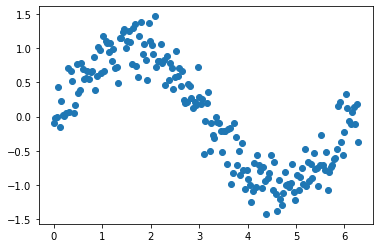

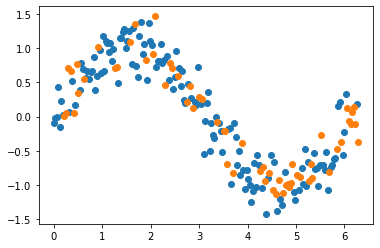

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

#DEFINE X DATA FOR PLOTTING
N=200; xmin=0; xmax=2*np.pi
x = np.linspace(xmin,xmax,N)
noise=np.random.normal(0,0.25,x.shape)
y=np.sin(x)+noise

# VISUALIZE BEFORE SPLIT
fig, ax = plt.subplots()
ax.plot(x,y,"o")
plt.show()

# RESHAPE
y=y.reshape(y.shape[0],1)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
X_train=X_train.reshape(X_train.shape[0],1)
X_test=X_test.reshape(X_test.shape[0],1)


## Defaults hyper-parameters

To begin, let's explore the model with mostly just the default hyper-parameters from `SkLearn`

Defaults
```
(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)
```

In [13]:
model=MLPRegressor(hidden_layer_sizes=[32,32],activation='tanh',early_stopping=True,tol=10**(-6),max_iter=1000,n_iter_no_change=50)
regr=model.fit(X_train, y_train)

/Users/jameshickman/miniconda3/envs/2022-anly503/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1599: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jameshickman/miniconda3/envs/2022-anly503/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Visualize the results

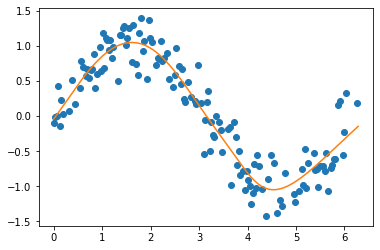

In [14]:
fig, ax = plt.subplots()
ax.plot(X_train,y_train,"o")
x1 = np.linspace(xmin,xmax,5*N,1).reshape(5*N,1)
ax.plot(x1,regr.predict(x1).reshape(-1,1),"-")
plt.show()

## 

### Visualize fitting history

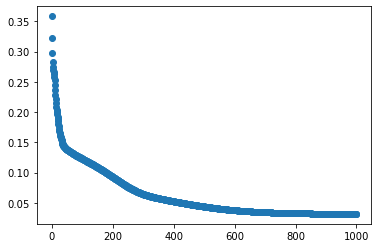

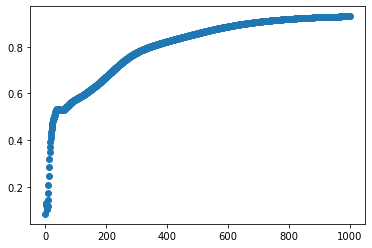

In [15]:
# print(regr.validation_scores_)
fig, ax = plt.subplots()
# training log-loss
ax.plot(regr.loss_curve_,"o")
plt.show()


fig, ax = plt.subplots()
# validtation R2
ax.plot(regr.validation_scores_,"o")
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error
# X_train, X_test, y_train, y_test
print(mean_squared_error(regr.predict(X_train),y_train))
print(mean_squared_error(regr.predict(X_test),y_test))

0.06136325026530662
0.048115049323252404


### Parameters

In [17]:
print("output activation",regr.out_activation_)
print("parameters")
for i in range(0,len(regr.coefs_)):
    print(regr.coefs_[i].shape)
    print(regr.intercepts_[i].shape)

output activation identity
parameters
(1, 32)
(32,)
(32, 32)
(32,)
(32, 1)
(1,)


## Over-fitting 

* Although ANN models are highly flexible, the default hyperparameter values in SkLearn tend to prevent over-fitting to some extent. 
* To induce over-fitting, we need to deliberately choose unfavorable hyper-parameters.
* In the upcoming example, we intentionally tweak the parameters to cause over-fitting.

/Users/jameshickman/miniconda3/envs/2022-anly503/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1599: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jameshickman/miniconda3/envs/2022-anly503/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25000) reached and the optimization hasn't converged yet.
  warnings.warn(


(1000, 1) (1000,)


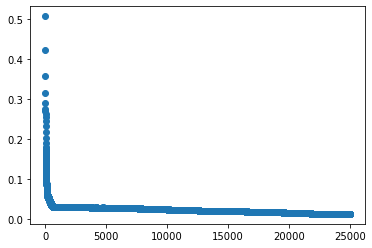

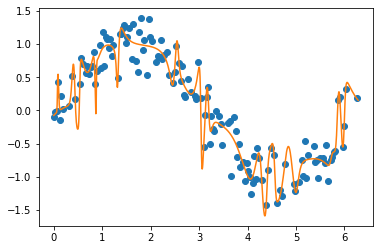

In [18]:
model=MLPRegressor(alpha=0.0,hidden_layer_sizes=[32,32,32],n_iter_no_change=10**10,activation="tanh",solver="adam", tol=10**(-15),max_iter=25000,learning_rate="constant")
regr=model.fit(X_train, y_train)

x1 = np.linspace(xmin,xmax,5*N,1).reshape(5*N,1)
print(x1.shape,regr.predict(x1).shape)

# print(regr.loss_curve_)
fig, ax = plt.subplots()
ax.plot(regr.loss_curve_,"o")
plt.show()

fig, ax = plt.subplots()
ax.plot(X_train,y_train,"o")
ax.plot(x1,regr.predict(x1).reshape(-1,1),"-")
plt.show()


**Further Demonstration**

* Explore and comment on the effect of various changes in hyper-parameters for `MLPRegressor` 

# Lab assignment

## Part-1: Python

Multi-class classification with ANN, do the following in python

**Q-1.1 Import and explore:** 

(1) Import MNIST from Sklearn, (2) print the shapes of the data and the target matrices (3) visualize a random MNIST image


**Q-1.2 Split data**: 

Break the data into an 80-20 training-test split. 

**Q-1.3 Logistic regression**

Train a multi-class logistic regression model as a base-line for comparison, do hyper-parameter search by varying  the `L2` regularization parameter, and record the training-validation error. Determine and report the optimal value of the `L2` regularization parameter. At the end train your best fit model using the optimal hyper-parameter and report the training-test error.

**Q-1.4: ANN training** 

* Do a multi-variable hyper-parameter search using a simplified version of `random search` for an ANN model. 
* Use the internal validation methods included with `sklearn.neural_network.MLPClassifier` for cross-validation.
    * Start with some initial guess for the hyper parameters with associate maximum step sizes
    * Introduce a `loop`, at each iteration
      * Randomly perturb the hyper-parameters (test <- current + random_change) and re-train 
      * Accept the change if you get a better model (lower validation error) ... repeat
    * **Optional**: Extend the search by using a distance metric to compute new points (see link below)

Choose 4 or more hyper-parameters to search for, e.g. `L2`,`activation`,`layer_size`, etc. Also, make sure to do early stopping during the search. Record the progression of the search in a data-frame and visualize the validation error results. 

[https://en.wikipedia.org/wiki/Random_search](https://en.wikipedia.org/wiki/Random_search)

Determine and report the optimal set of values for the parameters. At the end train your best fit model using the optimal hyper-parameter and report the training-test-validation error.


## Part-2: R

Complete the exercises below in an `.rmd` file.

### Q-2.1

Explore the web-application found at the following link

[click here](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.62835&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

Use the playground to create an architecture for logistic regression for binary classification. We'll have two inputs and one output. 



**Q-2.1.a** Use the training dataset where the two classes are easily separable, i.e. with two separated blobs in the upper and lower left quadrant. Train your model. How well does your classifier do? Provide a screenshot of the result. 


**Q-2.1.b** What are your fitted weights? Use those weights to compute (by hand) what the predicted probability for two arbitrary sample points, verify your intuition.

**Q-2.1.c** Now use the bullseye data and try to fit this data with logistic regression. Does it work? Provide a screenshot of the result. 

**Q-2.1.c** Try using different transformations of the data. See if you can get logistic regression to fit this data. Can you get it to separate with a single layer? 


**Q-2.1.d**  Explore adding hidden layers with 2 or 3 units and fit the model with different activations. Can you get it to work perfectly? Try adding another unit to the hidden layer. Comment on what is the simplest model that can still fit this dataset. Provide a screenshot of the result

**Q-2.1.e**
(i) Try the spiral-data set, which is more difficult. Try any architectures and activation functions that you want. How well can you do? What do you notice? Include a screenshot of your final model architecture.



### Q-2.2 

Let's verify that we understand the similarities between Neural Network and other models that we've talked about. 

Specifically, we'll establish that Multiple Regression (and Logistic Regression) are special cases of Neural Networks under very simple architectures.

First, we generate some sample data for simple regression.

In [ ]:
# IMPORT
library(nnet)

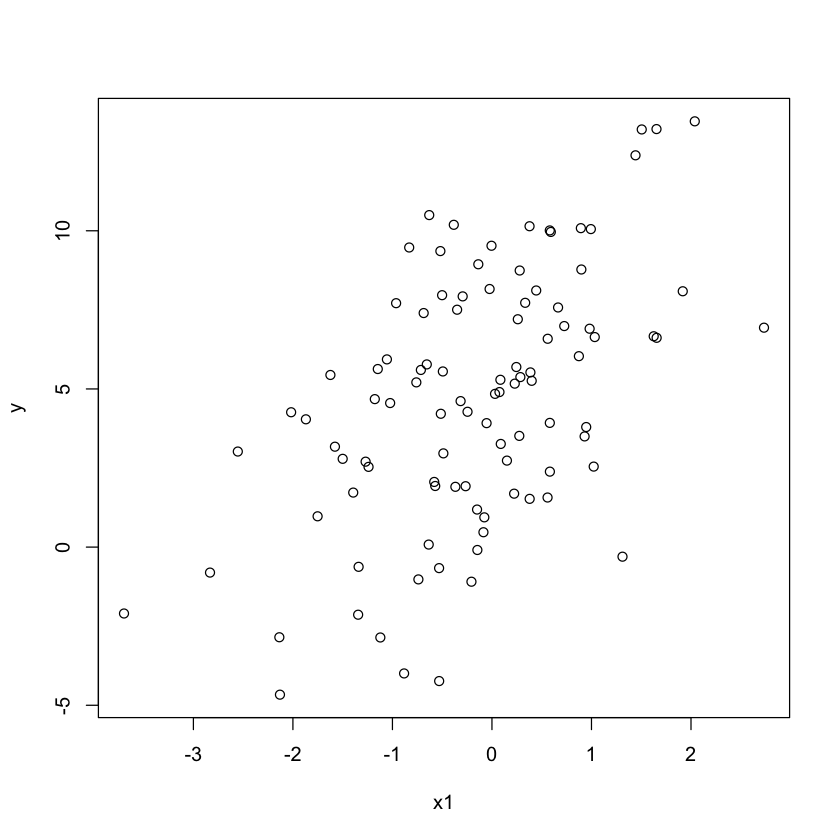

In [ ]:
x1 <- rnorm(100)
x2 <- rnorm(100)
y <- 5 +  2*x1 + -3*x2 + rnorm(100)
plot(x1,y)

df = data.frame(Y=y, X1 = x1, X2 = x2)

(a) Fit a linear model to this data in order to estimate the regression coefficients $\beta_0$ and $\beta_1$. Do this using built-in R methods we've learned previously.

(b) Let's do the same with a neural net, but one with a simple architecture. A neural net with no hidden layer just describes an architecture where each input feature is linearly combined (via some weights) to create an output feature. This will be identical to Multiple Regression if we have no non-linear transformations along the way. Create such a neural net with the nnet package and confirm that you can recover the right parameter weights. 

With nnet, to do regression output (as opposed to classification output), use the argument "linout = TRUE". Also, use the argument "skip = TRUE" to confirm that you intend to _skip_ the hidden layer and just go straight from the input to the output layer. Comments on the neural net architecture and weights, do they match your expectation?

(c) But we can choose any ANN architecture we like, we can have a complex an nonlinear model. Choose a model with a non-zero hidden layer and fit. Comment on the resulting error and model.

### Q-2.3

Neural Networks are "universal function approximators", which means if you have a big enough neural network, then it will be flexible enough to fit any function you wish. 

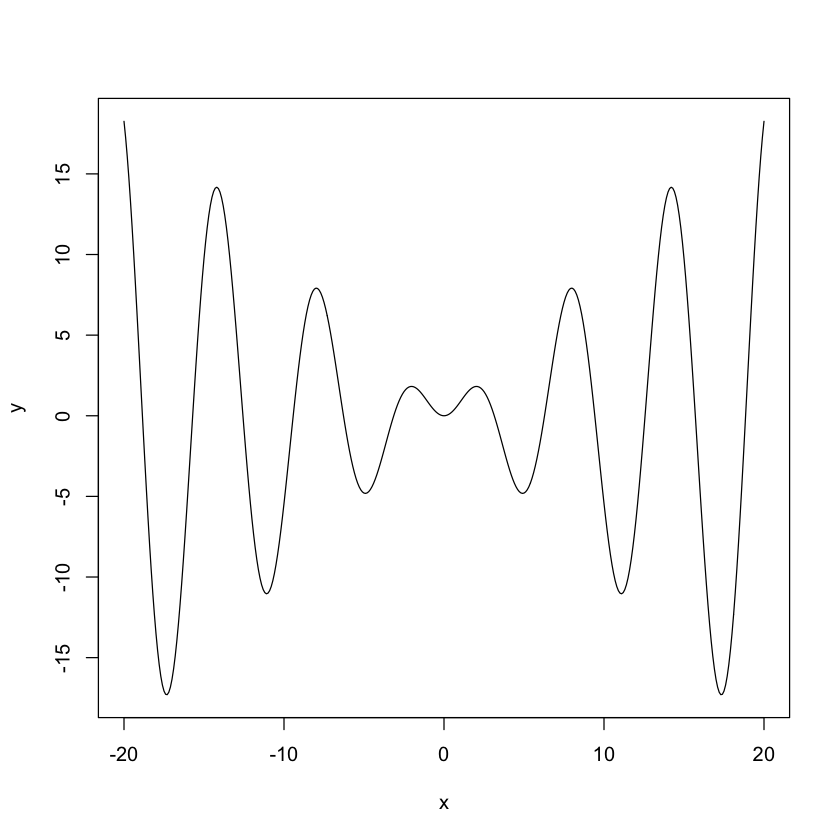

# weights:  61
initial  value 1355.788587 
iter  10 value 1062.797701
iter  20 value 909.823457
iter  30 value 524.059109
iter  40 value 210.296238
iter  50 value 191.178978
iter  60 value 176.814657
iter  70 value 145.312223
iter  80 value 118.199484
iter  90 value 113.407798
iter 100 value 109.015731
iter 110 value 96.055999
iter 120 value 42.524272
iter 130 value 33.616639
iter 140 value 23.853157
iter 150 value 16.073940
iter 160 value 13.060763
iter 170 value 11.500260
iter 180 value 10.721789
iter 190 value 10.331313
iter 200 value 10.153601
iter 210 value 10.061337
iter 220 value 9.980278
iter 230 value 9.955254
iter 240 value 9.935083
iter 250 value 9.873086
iter 260 value 9.824304
iter 270 value 9.796213
iter 280 value 9.781207
iter 290 value 9.760524
iter 300 value 9.739959
iter 310 value 9.719095
iter 320 value 9.704016
iter 330 value 9.696450
iter 340 value 9.690451
iter 350 value 9.685122
iter 360 value 9.683446
iter 370 value 9.675510
iter 380 value 9.671110
iter 390 valu

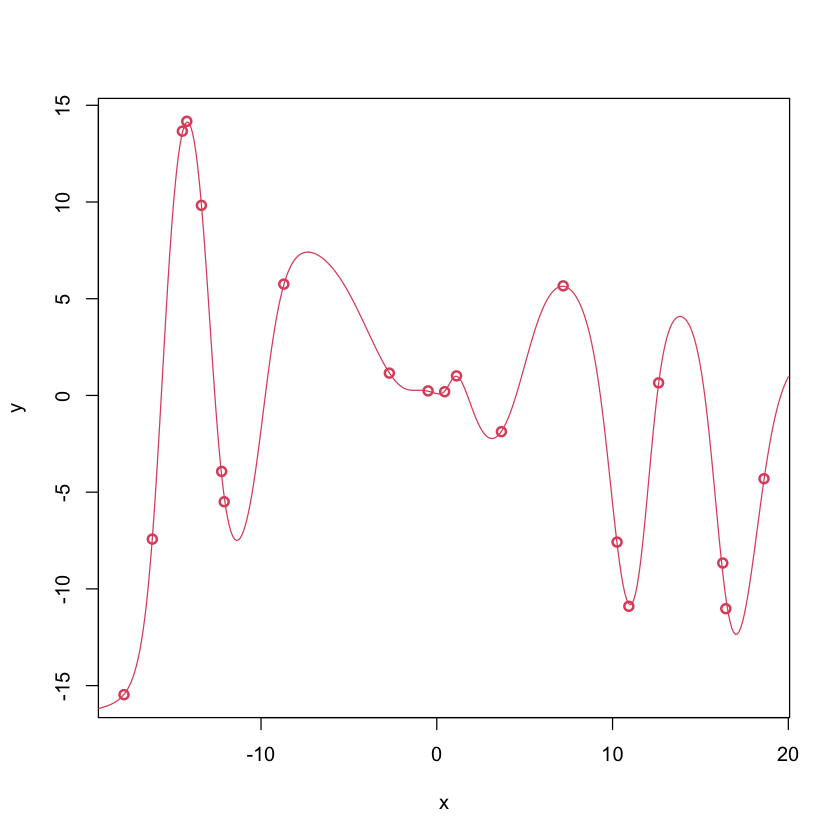

In [ ]:
sinc = function(x){x*sin(x)} # Define the function

xx <- seq(-20,20,by=.1) # vector of x variables for plotting
mydf = data.frame(x=xx, y = sinc(xx))

plot(y ~x, data = mydf, type = 'l')


# Now we will create a dataset by drawing a few samples from the domain of this function and evaluating this function at those locations.
x <- runif(20, min = -20, max = 20 )
mydf.train = data.frame(x = x, y = sinc(x))

plot(y ~x, data = mydf.train, lwd = 2, col = 2)

# Train network and make predictions
# Note linout = T
net1 <- nnet(y ~x, data = mydf.train, size = 20, decay = .001, maxit = 2000, linout = T)
pred <- predict(net1, newdata = mydf, type = "r")

# Make a plots of predictions, overlaid on the datapoints and the true function
lines(xx,pred, col = 2)

Repeat the above by changing the hyper-parameters of the model such as the size of the hidden layer. Plot the results. Be sure to include an example of a small model (such as size=2) and a large model (such as size=40). Comment on what you saw and how it relates to the bias-variance tradeoff. Thinking back to the phrase "universal function approximator", what would it take for a neural network to truly fit any complex function we wish?